In [ ]:
"""
=============================================================
  Adversarial Attacks Series — Note 01
  Fast Gradient Sign Method (FGSM) on MNIST
=============================================================

  Series:  Humble Model / Adversarial Awareness
  Dataset: MNIST
  Model:   Small CNN (~99% clean accuracy after 10 epochs)

  Notebook structure
  ──────────────────
  Part A │ Model definition & architecture
  Part B │ Data loading
  Part C │ Training loop with checkpoints
  Part D │ Evaluation on clean test set
  Part E │ FGSM attack function
  Part F │ Minimum-epsilon search across 500 test images
  Part G │ Best-example demo  (lowest flip-epsilon image)
  Part H │ Accuracy-vs-epsilon curve  (the citable result)
  Part I │ Summary printout

  Run the notebook top-to-bottom. Every section is self-contained
  given the variables defined above it.
=============================================================
"""

In [1]:
# ── Part A: Imports ──────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

In [2]:
# ── Part B: CNN Architecture ─────────────────────────────────────────────────

class CNN(nn.Module):
    """
    Small convolutional network for MNIST.

    fc1 is built dynamically on the first reset_for_input_size() call,
    so the same class works for any square input without manual arithmetic.
    """

    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)
        self.fc1: nn.Linear | None = None
        self.fc2 = nn.Linear(128, num_classes)
        self.flattened_size: int | None = None

    def reset_for_input_size(self, input_size: int) -> None:
        """Compute fc1 input dimension from a dry-run on a dummy tensor."""
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_size, input_size)
            x = F.max_pool2d(F.relu(self.conv1(dummy)), 2)
            x = F.max_pool2d(F.relu(self.conv2(x)), 2)
            self.flattened_size = x.view(1, -1).size(1)
            self.fc1 = nn.Linear(self.flattened_size, 128)
        print(f"🔄 Model initialised for {input_size}×{input_size} input "
              f"→ flattened size: {self.flattened_size}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.fc1 is None:
            raise RuntimeError("Call reset_for_input_size() before forward().")
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [3]:
# ── Part C: Data Loading ─────────────────────────────────────────────────────

# MNIST canonical normalisation constants
MEAN, STD = (0.1307,), (0.3081,)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

print(f"Training samples : {len(train_dataset):,}")
print(f"Test samples     : {len(test_dataset):,}")

100%|██████████| 9.91M/9.91M [00:08<00:00, 1.14MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 47.4kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 694kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 529kB/s]

Training samples : 60,000
Test samples     : 10,000


In [4]:
# ── Part D: Training with Checkpoints ───────────────────────────────────────

CHECKPOINT_PATH = "checkpoint_latest.pth"
NUM_EPOCHS      = 10
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model     = CNN().to(DEVICE)
model.reset_for_input_size(28)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
start_epoch = 0

# Resume from checkpoint if available
try:
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    print(f"✅ Resumed from checkpoint — starting at epoch {start_epoch}")
except FileNotFoundError:
    print("🆕 No checkpoint found — starting fresh training")

if start_epoch < NUM_EPOCHS:
    print("\n" + "="*55)
    print("🚀 Training")
    print("="*55)

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train()
        running_loss = 0.0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            if batch_idx % 200 == 0:
                print(f"  Epoch {epoch}  batch {batch_idx:>4}  loss {loss.item():.4f}")

        avg_loss = running_loss / len(train_loader)
        print(f"\n📊 Epoch {epoch} — avg loss: {avg_loss:.4f}")

        ckpt = {
            "epoch":               epoch,
            "model_state_dict":    model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss":                avg_loss,
            "flattened_size":      model.flattened_size,
        }
        torch.save(ckpt, CHECKPOINT_PATH)
        torch.save(ckpt, f"checkpoint_epoch_{epoch}.pth")
        print(f"💾 Checkpoint saved (epoch {epoch})")

    print("\n✅ Training complete!")
else:
    print("✅ Model already fully trained — skipping training loop.")

🔄 Model initialised for 28×28 input → flattened size: 800
🆕 No checkpoint found — starting fresh training

🚀 Training
  Epoch 0  batch    0  loss 2.3004
  Epoch 0  batch  200  loss 0.2340
  Epoch 0  batch  400  loss 0.1628
  Epoch 0  batch  600  loss 0.0788
  Epoch 0  batch  800  loss 0.2647

📊 Epoch 0 — avg loss: 0.1749
💾 Checkpoint saved (epoch 0)
  Epoch 1  batch    0  loss 0.0305
  Epoch 1  batch  200  loss 0.0817
  Epoch 1  batch  400  loss 0.1240
  Epoch 1  batch  600  loss 0.0062
  Epoch 1  batch  800  loss 0.0704

📊 Epoch 1 — avg loss: 0.0530
💾 Checkpoint saved (epoch 1)
  Epoch 2  batch    0  loss 0.0102
  Epoch 2  batch  200  loss 0.0452
  Epoch 2  batch  400  loss 0.0334
  Epoch 2  batch  600  loss 0.0063
  Epoch 2  batch  800  loss 0.0721

📊 Epoch 2 — avg loss: 0.0380
💾 Checkpoint saved (epoch 2)
  Epoch 3  batch    0  loss 0.0202
  Epoch 3  batch  200  loss 0.0105
  Epoch 3  batch  400  loss 0.0067
  Epoch 3  batch  600  loss 0.0175
  Epoch 3  batch  800  loss 0.0120

📊 Ep

In [5]:
# ── Part E: Clean Accuracy ───────────────────────────────────────────────────

model.eval()
correct = total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

clean_accuracy = 100 * correct / total
print(f"\n📈 Clean test accuracy: {clean_accuracy:.2f}%")


📈 Clean test accuracy: 99.02%


In [6]:
# ── Part F: FGSM Attack Function ─────────────────────────────────────────────

def fgsm_attack(
    image: torch.Tensor,
    epsilon: float,
    data_grad: torch.Tensor,
) -> torch.Tensor:
    """
    Single-step Fast Gradient Sign Method.

    Args:
        image:     Input tensor, shape [1, C, H, W], requires_grad=True.
        epsilon:   Perturbation magnitude (L∞ ball radius).
        data_grad: Gradient of loss w.r.t. image.

    Returns:
        Perturbed image clamped to [0, 1].
    """
    perturbed = image + epsilon * data_grad.sign()
    return torch.clamp(perturbed, 0, 1)


def get_gradient(model, image, label, criterion):
    """Return the loss gradient w.r.t. image. Image must require grad."""
    model.eval()
    image = image.clone().requires_grad_(True)
    output = model(image)
    loss = criterion(output, torch.tensor([label], device=image.device))
    model.zero_grad()
    loss.backward()
    return image.grad.data, output

In [7]:
# ── Part G: Minimum-Epsilon Search ───────────────────────────────────────────

'''   For each of the first N_SEARCH test images that the model classifies
   correctly on the clean input, we binary-search the smallest epsilon
   (from EPSILON_CANDIDATES) that causes a misclassification.

   This gives us:
     • A distribution of "how fragile is each image?"
     • The best demo image: the one that flips at the lowest epsilon
       (strongest argument for imperceptibility).
'''

N_SEARCH         = 500                                    # images to probe- from 100 to 500 
EPSILON_GRID     = np.round(np.arange(0.01, 0.41, 0.01), 2).tolist()  # 0.01…0.40

print("\n" + "="*55)
print(f"🔍 Minimum-epsilon search over {N_SEARCH} test images")
print("="*55)

results = []          # list of dicts: {idx, label, min_eps, adv_pred, image, adv_image}
tested  = 0
found   = 0

for idx in range(len(test_dataset)):
    if found >= N_SEARCH:
        break

    raw_image, label = test_dataset[idx]
    raw_image = raw_image.unsqueeze(0).to(DEVICE)

    # Skip if the model already misclassifies the clean image
    with torch.no_grad():
        clean_out  = model(raw_image)
        clean_pred = clean_out.argmax().item()
    if clean_pred != label:
        continue

    tested += 1
    grad, _ = get_gradient(model, raw_image, label, criterion)

    min_eps   = None
    adv_image = None
    adv_pred  = None

    for eps in EPSILON_GRID:
        perturbed = fgsm_attack(raw_image, eps, grad)
        with torch.no_grad():
            out  = model(perturbed)
            pred = out.argmax().item()
        if pred != label:
            min_eps   = eps
            adv_image = perturbed
            adv_pred  = pred
            break

    results.append({
        "idx":       idx,
        "label":     label,
        "min_eps":   min_eps,          # None → never flipped within grid
        "adv_pred":  adv_pred,
        "image":     raw_image.cpu(),
        "adv_image": adv_image.cpu() if adv_image is not None else None,
        "grad":      grad.cpu(),
    })
    found += 1

    if found % 20 == 0:
        flipped = sum(1 for r in results if r["min_eps"] is not None)
        print(f"  Probed {found}/{N_SEARCH} — {flipped} flipped so far")

# ── Summary statistics ────────────────────────────────────────────────────────

flipped_results = [r for r in results if r["min_eps"] is not None]
never_flipped   = [r for r in results if r["min_eps"] is None]

eps_values = [r["min_eps"] for r in flipped_results]

print(f"\n📊 Minimum-epsilon search results ({N_SEARCH} images)")
print(f"   Successfully flipped : {len(flipped_results)}")
print(f"   Never flipped (ε≤0.40): {len(never_flipped)}")
if eps_values:
    print(f"   Min   ε to flip : {min(eps_values):.2f}")
    print(f"   Median ε to flip : {np.median(eps_values):.2f}")
    print(f"   Max   ε to flip : {max(eps_values):.2f}")
    


🔍 Minimum-epsilon search over 500 test images
  Probed 20/500 — 2 flipped so far
  Probed 40/500 — 2 flipped so far
  Probed 60/500 — 2 flipped so far
  Probed 80/500 — 4 flipped so far
  Probed 100/500 — 4 flipped so far
  Probed 120/500 — 4 flipped so far
  Probed 140/500 — 5 flipped so far
  Probed 160/500 — 6 flipped so far
  Probed 180/500 — 7 flipped so far
  Probed 200/500 — 8 flipped so far
  Probed 220/500 — 8 flipped so far
  Probed 240/500 — 8 flipped so far
  Probed 260/500 — 9 flipped so far
  Probed 280/500 — 10 flipped so far
  Probed 300/500 — 11 flipped so far
  Probed 320/500 — 12 flipped so far
  Probed 340/500 — 14 flipped so far
  Probed 360/500 — 14 flipped so far
  Probed 380/500 — 14 flipped so far
  Probed 400/500 — 14 flipped so far
  Probed 420/500 — 15 flipped so far
  Probed 440/500 — 15 flipped so far
  Probed 460/500 — 17 flipped so far
  Probed 480/500 — 17 flipped so far
  Probed 500/500 — 18 flipped so far

📊 Minimum-epsilon search results (500 images


🎯 Best demo image
   Test-set index  : 8
   True label      : 5
   Min flip-epsilon: ε = 0.01
   Clean  → label 5  (confidence 0.9511)
   Advers → label 6  (confidence 0.3831)


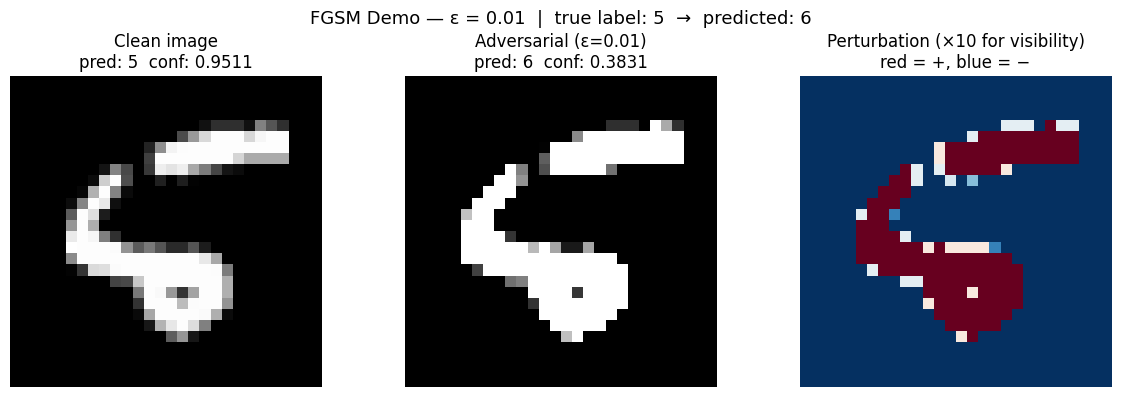

📷 Figure saved → fgsm_best_demo.png


In [8]:
# ── Part H: Best-Example Demo ────────────────────────────────────────────────

'''   The "best" demo is the image with the lowest flip-epsilon.
   It is honest: we show the actual minimum perturbation that fools
   the model, and we acknowledge exactly what that epsilon means visually. 
'''

if flipped_results:
    best = min(flipped_results, key=lambda r: r["min_eps"])

    clean_img  = best["image"].squeeze()          # [28, 28]
    adv_img    = best["adv_image"].squeeze()
    perturbation = (adv_img - clean_img)

    # Confidence scores
    model.eval()
    with torch.no_grad():
        c_out = model(best["image"].to(DEVICE))
        a_out = model(best["adv_image"].to(DEVICE))

    c_conf = torch.softmax(c_out, dim=1)[0, best["label"]].item()
    a_conf = torch.softmax(a_out, dim=1)[0, best["adv_pred"]].item()

    print("\n" + "="*55)
    print("🎯 Best demo image")
    print("="*55)
    print(f"   Test-set index  : {best['idx']}")
    print(f"   True label      : {best['label']}")
    print(f"   Min flip-epsilon: ε = {best['min_eps']:.2f}")
    print(f"   Clean  → label {best['label']}  (confidence {c_conf:.4f})")
    print(f"   Advers → label {best['adv_pred']}  (confidence {a_conf:.4f})")

    # ── Figure 1: clean / adversarial / perturbation ──────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(
        f"FGSM Demo — ε = {best['min_eps']:.2f}  |  "
        f"true label: {best['label']}  →  predicted: {best['adv_pred']}",
        fontsize=13
    )

    axes[0].imshow(clean_img.numpy(), cmap="gray")
    axes[0].set_title(f"Clean image\npred: {best['label']}  conf: {c_conf:.4f}")
    axes[0].axis("off")

    axes[1].imshow(adv_img.numpy(), cmap="gray")
    axes[1].set_title(f"Adversarial (ε={best['min_eps']:.2f})\npred: {best['adv_pred']}  conf: {a_conf:.4f}")
    axes[1].axis("off")

    axes[2].imshow(perturbation.numpy() * 10, cmap="RdBu", vmin=-1, vmax=1)
    axes[2].set_title("Perturbation (×10 for visibility)\nred = +, blue = −")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig("fgsm_best_demo.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("📷 Figure saved → fgsm_best_demo.png")
else:
    print("⚠️  No image was flipped within ε ≤ 0.40. "
          "Check that the model is fully trained.")


📈 Building accuracy-vs-epsilon curve


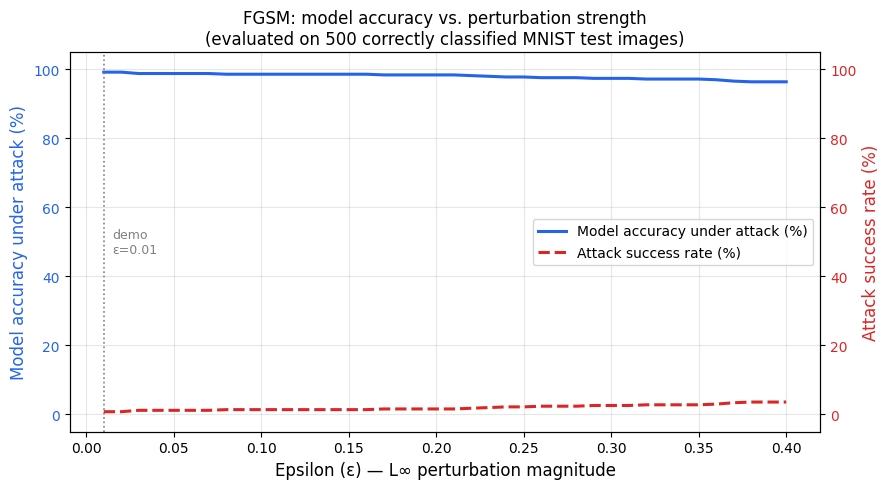

📷 Figure saved → fgsm_epsilon_curve.png


In [9]:
# ── Part I: Accuracy-vs-Epsilon Curve ────────────────────────────────────────

'''   
    For each epsilon in EPSILON_GRID, compute the fraction of the N_SEARCH
   images that FGSM successfully flips (attack success rate).
   This is the citable empirical result: it shows the attack is real,
   makes the detectability trade-off explicit, and requires no cherry-picking.

   We use the pre-computed gradients from the search above, so this costs
   no additional forward/backward passes.
'''

print("\n" + "="*55)
print("📈 Building accuracy-vs-epsilon curve")
print("="*55)

epsilons      = EPSILON_GRID
success_rates = []

for eps in epsilons:
    successes = 0
    for r in results:
        if r["min_eps"] is not None and r["min_eps"] <= eps:
            successes += 1
    rate = successes / len(results)
    success_rates.append(rate)

# Mirror as model accuracy under attack (1 - success_rate)
accuracy_under_attack = [1 - s for s in success_rates]

# ── Figure 2: the curve ────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 5))

color_acc     = "#2563EB"   # blue   — model accuracy
color_success = "#DC2626"   # red    — attack success

ax2 = ax1.twinx()

ax1.plot(epsilons, [a * 100 for a in accuracy_under_attack],
         color=color_acc, linewidth=2.2, label="Model accuracy under attack (%)")
ax1.set_ylabel("Model accuracy under attack (%)", color=color_acc, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_acc)
ax1.set_ylim(-5, 105)

ax2.plot(epsilons, [s * 100 for s in success_rates],
         color=color_success, linewidth=2.2, linestyle="--",
         label="Attack success rate (%)")
ax2.set_ylabel("Attack success rate (%)", color=color_success, fontsize=12)
ax2.tick_params(axis="y", labelcolor=color_success)
ax2.set_ylim(-5, 105)

# Mark the best-demo epsilon
if flipped_results:
    demo_eps = best["min_eps"]
    ax1.axvline(demo_eps, color="gray", linewidth=1.2, linestyle=":")
    ax1.text(demo_eps + 0.005, 50,
             f"demo\nε={demo_eps:.2f}",
             color="gray", fontsize=9, va="center")

ax1.set_xlabel("Epsilon (ε) — L∞ perturbation magnitude", fontsize=12)
ax1.set_title(
    f"FGSM: model accuracy vs. perturbation strength\n"
    f"(evaluated on {len(results)} correctly classified MNIST test images)",
    fontsize=12
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=10)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fgsm_epsilon_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("📷 Figure saved → fgsm_epsilon_curve.png")

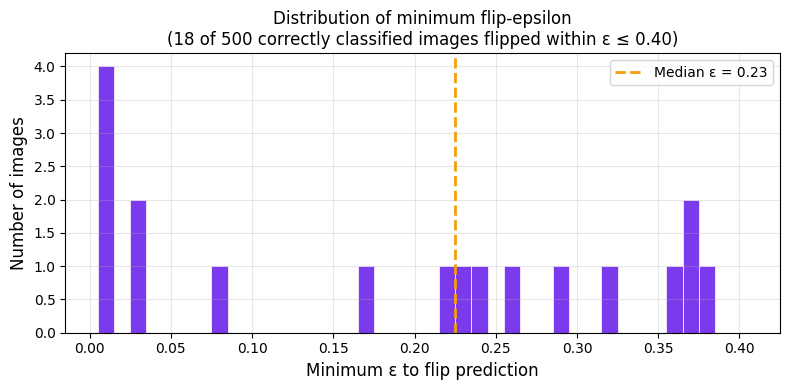

📷 Figure saved → fgsm_eps_distribution.png


In [10]:
# ── Part J: Minimum-Epsilon Distribution ─────────────────────────────────────

'''   
    Histogram of the minimum flip-epsilon across all images that were
   successfully flipped. Gives the reader intuition about how far the
   decision boundary sits from the data manifold. 
'''

if flipped_results:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(eps_values, bins=np.arange(0.005, 0.415, 0.01),
            color="#7C3AED", edgecolor="white", linewidth=0.5)
    ax.axvline(np.median(eps_values), color="#F59E0B", linewidth=2,
               linestyle="--", label=f"Median ε = {np.median(eps_values):.2f}")
    ax.set_xlabel("Minimum ε to flip prediction", fontsize=12)
    ax.set_ylabel("Number of images", fontsize=12)
    ax.set_title(
        f"Distribution of minimum flip-epsilon\n"
        f"({len(flipped_results)} of {N_SEARCH} correctly classified images flipped within ε ≤ 0.40)",
        fontsize=12
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("fgsm_eps_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("📷 Figure saved → fgsm_eps_distribution.png")

In [12]:
# ── Part K: Final Summary ─────────────────────────────────────────────────────

print("\n" + "="*55)
print("📋 Experiment Summary")
print("="*55)
print(f"  Model clean accuracy          : {clean_accuracy:.2f}%")
print(f"  Images probed                 : {len(results)}")
print(f"  Images flipped (ε ≤ 0.40)    : {len(flipped_results)}")
if eps_values:
    print(f"  Median minimum flip-epsilon   : {np.median(eps_values):.2f}")
    print(f"  Best demo ε (lowest flip)     : {min(eps_values):.2f}")
    # Find attack success rate at median
    med = np.median(eps_values)
    idx_med = min(range(len(epsilons)), key=lambda i: abs(epsilons[i] - med))
    print(f"  Attack success at median ε    : {success_rates[idx_med]*100:.1f}%")
    print(f"  Model accuracy at median ε    : {accuracy_under_attack[idx_med]*100:.1f}%")
print("\n  Output files:")
print("    fgsm_best_demo.png       — Figure 1 (clean / adv / perturbation)")
print("    fgsm_epsilon_curve.png   — Figure 2 (accuracy vs ε curve)")
print("    fgsm_eps_distribution.png — Figure 3 (flip-epsilon histogram)")
print("    checkpoint_latest.pth    — trained model weights")


📋 Experiment Summary
  Model clean accuracy          : 99.19%
  Images probed                 : 500
  Images flipped (ε ≤ 0.40)    : 22
  Median minimum flip-epsilon   : 0.24
  Best demo ε (lowest flip)     : 0.01
  Attack success at median ε    : 2.4%
  Model accuracy at median ε    : 97.6%

  Output files:
    fgsm_best_demo.png       — Figure 1 (clean / adv / perturbation)
    fgsm_epsilon_curve.png   — Figure 2 (accuracy vs ε curve)
    fgsm_eps_distribution.png — Figure 3 (flip-epsilon histogram)
    checkpoint_latest.pth    — trained model weights
